In [1]:
!pip install  -q torch torchvision opencv-python tqdm matplotlib

In [3]:
import os, json, math, random
from typing import Optional, Tuple

import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision

In [2]:
# Download FreiHAND
!wget https://lmb.informatik.uni-freiburg.de/data/freihand/FreiHAND_pub_v2.zip
!unzip -q FreiHAND_pub_v2.zip -d /content/FreiHAND

--2025-12-14 03:56:21--  https://lmb.informatik.uni-freiburg.de/data/freihand/FreiHAND_pub_v2.zip
Resolving lmb.informatik.uni-freiburg.de (lmb.informatik.uni-freiburg.de)... 132.230.167.23
Connecting to lmb.informatik.uni-freiburg.de (lmb.informatik.uni-freiburg.de)|132.230.167.23|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3881833583 (3.6G) [application/zip]
Saving to: ‘FreiHAND_pub_v2.zip’

FreiHAND_pub_v2.zip 100%[===================>]   3.62G  19.0MB/s    in 3m 18s  

2025-12-14 03:59:40 (18.7 MB/s) - ‘FreiHAND_pub_v2.zip’ saved [3881833583/3881833583]



In [4]:
# CONFIG
FREIHAND_ROOT = "/content/FreiHAND"

RGB_DIR = os.path.join(FREIHAND_ROOT, "training", "rgb")
XYZ_JSON = os.path.join(FREIHAND_ROOT, "training_xyz.json")
K_JSON = os.path.join(FREIHAND_ROOT, "training_K.json")

# image/heatmap size
IN_SIZE = 224
HM_SIZE = 56
SIGMA = 2.0

# training
BATCH_SIZE = 32
EPOCHS = 50
LR = 3e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2

# split
VAL_RATIO = 0.1
SEED = 42

# crop margin
CROP_MARGIN = 0.25

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Sanity checks
assert os.path.isdir(RGB_DIR), f"RGB_DIR not found: {RGB_DIR}"
assert os.path.isfile(XYZ_JSON), f"XYZ_JSON not found: {XYZ_JSON}"
assert os.path.isfile(K_JSON),   f"K_JSON not found: {K_JSON}"

Device: cuda


In [5]:
# 3D to 2D
def project_xyz_to_uv(xyz: np.ndarray, K: np.ndarray) -> np.ndarray:
    """
    Project 3D keypoints (J,3) -> 2D pixels (J,2) using camera intrinsics K (3,3).
    xyz is in camera coordinates; K gives fx, fy, cx, cy.
    """
    X = xyz[:, 0]
    Y = xyz[:, 1]
    Z = np.clip(xyz[:, 2], 1e-6, None)

    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]

    u = fx * (X / Z) + cx
    v = fy * (Y / Z) + cy
    return np.stack([u, v], axis=1)


def bbox_from_points(uv: np.ndarray, w: int, h: int, margin: float = 0.25) -> Tuple[int,int,int,int]:
    """
    Create a square-ish bbox around 2D points with margin.
    Returns (x0,y0,x1,y1) in inclusive-exclusive format.
    """
    x_min, y_min = uv.min(axis=0)
    x_max, y_max = uv.max(axis=0)

    bw = x_max - x_min
    bh = y_max - y_min
    side = max(bw, bh) * (1.0 + margin)

    cx = (x_min + x_max) * 0.5
    cy = (y_min + y_max) * 0.5

    x0 = int(round(cx - side * 0.5))
    y0 = int(round(cy - side * 0.5))
    x1 = int(round(cx + side * 0.5))
    y1 = int(round(cy + side * 0.5))

    # clamp to image
    x0 = max(0, x0); y0 = max(0, y0)
    x1 = min(w, x1); y1 = min(h, y1)

    # ensure non-empty
    if x1 <= x0 + 1: x1 = min(w, x0 + 2)
    if y1 <= y0 + 1: y1 = min(h, y0 + 2)

    return x0, y0, x1, y1


def crop_and_resize(img: np.ndarray, uv: np.ndarray, bbox: Tuple[int,int,int,int], out_size: int = 224):
    """
    Crop bbox from img, resize to out_size x out_size.
    Transform uv into resized crop coordinates.
    Returns: crop_resized, uv_crop_resized, valid_mask
    """
    x0, y0, x1, y1 = bbox
    crop = img[y0:y1, x0:x1]
    ch, cw = crop.shape[:2]

    crop_resized = cv2.resize(crop, (out_size, out_size), interpolation=cv2.INTER_LINEAR)

    uv_crop = uv.copy()
    uv_crop[:, 0] = (uv[:, 0] - x0) * (out_size / max(cw, 1))
    uv_crop[:, 1] = (uv[:, 1] - y0) * (out_size / max(ch, 1))

    valid = (uv_crop[:, 0] >= 0) & (uv_crop[:, 0] < out_size) & (uv_crop[:, 1] >= 0) & (uv_crop[:, 1] < out_size)
    return crop_resized, uv_crop, valid.astype(np.float32)


In [6]:
# heatmap
def draw_gaussian_heatmaps(kp_xy_hm: torch.Tensor, hm_size: int = 56, sigma: float = 2.0,
                           valid: Optional[torch.Tensor] = None) -> torch.Tensor:
    """
    kp_xy_hm: (J,2) coordinates in heatmap space
    valid: (J,) 0/1 mask
    Returns: (J, hm_size, hm_size)
    """
    device = kp_xy_hm.device
    J = kp_xy_hm.shape[0]

    if valid is None:
        valid = torch.ones(J, device=device, dtype=torch.float32)
    else:
        valid = valid.float().to(device)

    ys = torch.arange(hm_size, device=device).view(1, hm_size, 1)
    xs = torch.arange(hm_size, device=device).view(1, 1, hm_size)

    x0 = kp_xy_hm[:, 0].view(J, 1, 1)
    y0 = kp_xy_hm[:, 1].view(J, 1, 1)

    g = torch.exp(-((xs - x0) ** 2 + (ys - y0) ** 2) / (2 * sigma ** 2))
    return g * valid.view(J, 1, 1)

# decoding
def heatmaps_to_coords_argmax(hm: torch.Tensor) -> torch.Tensor:
    """
    hm: (B,J,H,W)
    Returns coords in heatmap space: (B,J,2) (x,y)
    """
    B, J, H, W = hm.shape
    flat = hm.view(B, J, -1)
    idx = flat.argmax(dim=-1)

    y = (idx // W).float()
    x = (idx % W).float()
    return torch.stack([x, y], dim=-1)


In [7]:
class FreiHANDHeatmapDataset(Dataset):
    def __init__(self, rgb_dir: str, xyz_json: str, K_json: str,
                 indices: np.ndarray,
                 in_size: int = 224, hm_size: int = 56, sigma: float = 2.0,
                 crop_margin: float = 0.25,
                 augment: bool = True):
        self.rgb_dir = rgb_dir
        self.in_size = in_size
        self.hm_size = hm_size
        self.sigma = sigma
        self.crop_margin = crop_margin
        self.augment = augment

        with open(xyz_json, "r") as f:
            self.xyz_all = np.array(json.load(f), dtype=np.float32)  # (N,21,3)
        with open(K_json, "r") as f:
            self.K_all = np.array(json.load(f), dtype=np.float32)    # (N,3,3)

        self.indices = indices.astype(np.int64)

    def __len__(self):
        return len(self.indices)

    def _augment_img_and_uv(self, img, uv):
        """
        Simple augmentation in full-image space:
        - random horizontal flip
        - random affine rotate/scale/translate
        """
        h, w = img.shape[:2]

        # flip
        if random.random() < 0.5:
            img = img[:, ::-1, :]
            uv = uv.copy()
            uv[:, 0] = (w - 1) - uv[:, 0]

        # affine
        angle = random.uniform(-20, 20)
        scale = random.uniform(0.9, 1.1)
        tx = random.uniform(-10, 10)
        ty = random.uniform(-10, 10)

        M = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
        M[0, 2] += tx
        M[1, 2] += ty

        img2 = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)

        uv_h = np.concatenate([uv, np.ones((uv.shape[0], 1), dtype=np.float32)], axis=1)
        uv2 = (M @ uv_h.T).T
        return img2, uv2

    def __getitem__(self, i):
        idx = int(self.indices[i])

        # FreiHAND typical filename: 00000000.jpg
        img_path = os.path.join(self.rgb_dir, f"{idx:08d}.jpg")
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"Could not read image: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]

        xyz = self.xyz_all[idx]  # (21,3)
        K = self.K_all[idx]      # (3,3)

        uv = project_xyz_to_uv(xyz, K)  # (21,2) in full-image pixels

        if self.augment:
            img, uv = self._augment_img_and_uv(img, uv)

        bbox = bbox_from_points(uv, W, H, margin=self.crop_margin)
        crop, uv_crop, valid = crop_and_resize(img, uv, bbox, out_size=self.in_size)

        # to tensor (3,IN,IN)
        crop_t = torch.from_numpy(crop).permute(2, 0, 1).float() / 255.0

        # MobileNetV3 pretrained expects ImageNet normalization
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        crop_t = (crop_t - mean) / std

        uv_crop_t = torch.from_numpy(uv_crop).float()   # (21,2) in IN space
        valid_t = torch.from_numpy(valid).float()       # (21,)

        # build GT heatmaps (in HM space)
        scale = self.hm_size / self.in_size
        kp_hm = uv_crop_t * scale
        hm = draw_gaussian_heatmaps(kp_hm, hm_size=self.hm_size, sigma=self.sigma, valid=valid_t)

        return {
            "image": crop_t,
            "heatmaps": hm,
            "valid": valid_t,
            "uv_in": uv_crop_t,  # GT coords in input space (224)
        }


In [8]:
# Get dataset size
with open(XYZ_JSON, "r") as f:
    xyz_all = json.load(f)
N = len(xyz_all)
print("Total samples:", N)

rng = np.random.default_rng(SEED)
all_indices = np.arange(N)
rng.shuffle(all_indices)

val_n = int(N * VAL_RATIO)
val_idx = all_indices[:val_n]
train_idx = all_indices[val_n:]

train_ds = FreiHANDHeatmapDataset(RGB_DIR, XYZ_JSON, K_JSON, train_idx,
                                  in_size=IN_SIZE, hm_size=HM_SIZE, sigma=SIGMA,
                                  crop_margin=CROP_MARGIN, augment=True)
val_ds = FreiHANDHeatmapDataset(RGB_DIR, XYZ_JSON, K_JSON, val_idx,
                                in_size=IN_SIZE, hm_size=HM_SIZE, sigma=SIGMA,
                                crop_margin=CROP_MARGIN, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

print("Train batches:", len(train_loader), "Val batches:", len(val_loader))


Total samples: 32560
Train batches: 915 Val batches: 102


In [9]:
class MobileNetV3Heatmap(nn.Module):
    def __init__(self, num_joints=21, hm_size=56, pretrained=True):
        super().__init__()
        self.hm_size = hm_size

        weights = "DEFAULT" if pretrained else None
        base = torchvision.models.mobilenet_v3_large(weights=weights)

        # backbone features only
        self.backbone = base.features  # stride ~32
        backbone_out_ch = 960

        # lightweight head: conv + upsample x3 -> final 21 heatmaps
        self.head = nn.Sequential(
            nn.Conv2d(backbone_out_ch, 256, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(256, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(64, num_joints, 1),
        )

    def forward(self, x):
        feat = self.backbone(x)
        hm = self.head(feat)
        # force exact heatmap resolution
        hm = nn.functional.interpolate(hm, size=(self.hm_size, self.hm_size),
                                       mode="bilinear", align_corners=False)
        return hm


In [10]:
def heatmap_mse_loss(pred, target, valid=None):
    """
    Masked MSE.
    pred/target: (B,J,H,W)
    valid: (B,J) mask
    """
    if valid is None:
        return ((pred - target) ** 2).mean()

    valid = valid.float().unsqueeze(-1).unsqueeze(-1)  # (B,J,1,1)
    diff2 = (pred - target) ** 2 * valid
    denom = valid.sum() * pred.shape[-1] * pred.shape[-2] + 1e-8
    return diff2.sum() / denom


@torch.no_grad()
def mean_pixel_error_in_input_space(hm_pred, uv_gt_in, in_size=224, hm_size=56, valid=None):
    """
    Decode heatmaps -> coords -> compute average distance in INPUT pixels (224-space).
    """
    coords_hm = heatmaps_to_coords_argmax(hm_pred)        # (B,J,2) heatmap coords
    coords_in = coords_hm * (in_size / hm_size)           # scale to 224 space

    diff = coords_in - uv_gt_in
    dist = torch.sqrt((diff ** 2).sum(dim=-1))            # (B,J)

    if valid is not None:
        dist = dist * valid
        denom = valid.sum() + 1e-8
        return dist.sum().item() / denom.item()
    return dist.mean().item()


In [11]:
model = MobileNetV3Heatmap(num_joints=21, hm_size=HM_SIZE, pretrained=True).to(device)

opt = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

use_amp = (device == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

def run_one_epoch(loader, train: bool):
    model.train(train)
    total_loss = 0.0
    total_mpe = 0.0
    n = 0

    pbar = tqdm(loader, desc=("train" if train else "val"), leave=False)
    for batch in pbar:
        imgs = batch["image"].to(device, non_blocking=True)
        hm_gt = batch["heatmaps"].to(device, non_blocking=True)
        valid = batch["valid"].to(device, non_blocking=True)
        uv_gt_in = batch["uv_in"].to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            hm_pred = model(imgs)
            loss = heatmap_mse_loss(hm_pred, hm_gt, valid=valid)

        if train:
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

        mpe = mean_pixel_error_in_input_space(hm_pred, uv_gt_in, in_size=IN_SIZE, hm_size=HM_SIZE, valid=valid)

        total_loss += loss.item()
        total_mpe += mpe
        n += 1
        pbar.set_postfix(loss=total_loss/n, mpe_px=total_mpe/n)

    return total_loss / max(n, 1), total_mpe / max(n, 1)


best_val = 1e9
os.makedirs("checkpoints", exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_mpe = run_one_epoch(train_loader, train=True)
    va_loss, va_mpe = run_one_epoch(val_loader, train=False)
    scheduler.step()

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train loss {tr_loss:.5f}, mpe {tr_mpe:.2f}px | "
          f"val loss {va_loss:.5f}, mpe {va_mpe:.2f}px")

    if va_mpe < best_val:
        best_val = va_mpe
        torch.save({
            "epoch": epoch,
            "model": model.state_dict(),
            "opt": opt.state_dict(),
            "val_mpe": va_mpe,
            "config": {
                "IN_SIZE": IN_SIZE, "HM_SIZE": HM_SIZE, "SIGMA": SIGMA,
                "CROP_MARGIN": CROP_MARGIN
            }
        }, "checkpoints/best.pt")
        print("✅ Saved checkpoints/best.pt")


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 119MB/s]
/tmp/ipython-input-890385857.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
train:   0%|          | 0/915 [00:00<?, ?it/s]/tmp/ipython-input-890385857.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 01/50 | train loss 0.00491, mpe 68.66px | val loss 0.00360, mpe 38.93px
✅ Saved checkpoints/best.pt


Epoch 02/50 | train loss 0.00339, mpe 32.30px | val loss 0.00315, mpe 26.09px
✅ Saved checkpoints/best.pt


Epoch 03/50 | train loss 0.00296, mpe 22.78px | val loss 0.00275, mpe 19.38px
✅ Saved checkpoints/best.pt


...

Epoch 28/50 | train loss 0.00105, mpe 6.44px | val loss 0.00131, mpe 8.08px


Epoch 29/50 | train loss 0.00103, mpe 6.33px | val loss 0.00128, mpe 7.92px
✅ Saved checkpoints/best.pt


Epoch 30/50 | train loss 0.00101, mpe 6.23px | val loss 0.00127, mpe 7.88px
✅ Saved checkpoints/best.pt


Epoch 31/50 | train loss 0.00099, mpe 6.12px | val loss 0.00127, mpe 7.78px
✅ Saved checkpoints/best.pt


KeyboardInterrupt: 

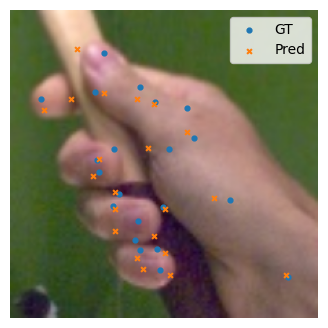

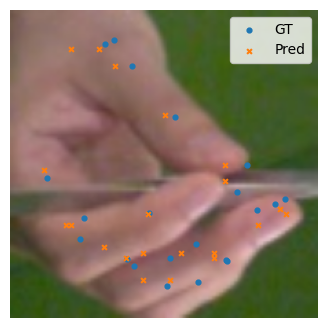

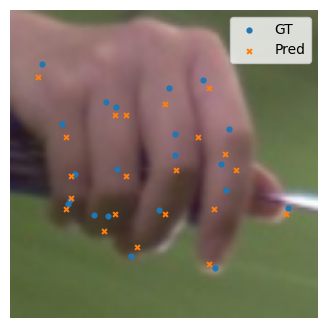

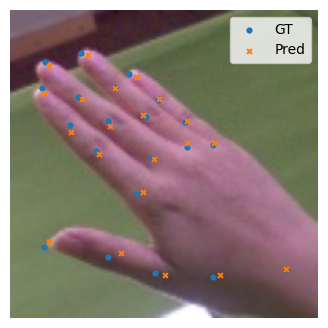

In [12]:
@torch.no_grad()
def denorm_img(img_t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    x = img_t.cpu() * std + mean
    x = (x.clamp(0,1).permute(1,2,0).numpy() * 255).astype(np.uint8)
    return x

@torch.no_grad()
def show_batch(n=4):
    batch = next(iter(val_loader))
    imgs = batch["image"].to(device)
    uv_gt = batch["uv_in"].to(device)
    valid = batch["valid"].to(device)

    hm_pred = model(imgs)
    coords_hm = heatmaps_to_coords_argmax(hm_pred)
    coords_in = coords_hm * (IN_SIZE / HM_SIZE)

    for i in range(min(n, imgs.shape[0])):
        img = denorm_img(imgs[i])
        pred = coords_in[i].cpu().numpy()
        gt = uv_gt[i].cpu().numpy()
        m = valid[i].cpu().numpy().astype(bool)

        plt.figure(figsize=(4,4))
        plt.imshow(img)
        plt.scatter(gt[m,0], gt[m,1], s=12, marker='o', label="GT")
        plt.scatter(pred[m,0], pred[m,1], s=12, marker='x', label="Pred")
        plt.legend()
        plt.axis("off")
        plt.show()

show_batch(n=4)
